In [8]:
# Setup
from pyspark.sql import SparkSession
from pyspark.sql import functions as f

spark = SparkSession.builder \
    .appName("BDLC_Parking_Violations_Diagnose") \
    .master("spark://bdlc-012.bdlc.ls.eee.intern:7077") \
    .config("spark.executor.cores", "2") \
    .config("spark.executor.memory", "8g") \
    .config("spark.cores.max", "18") \
    .getOrCreate()
spark.sparkContext.setLogLevel("WARN")

# Daten laden
processed_path = "hdfs:///parking_violations/processed/parking_violations_cleaned"
df = spark.read.parquet(processed_path)

# Kurzer Sanity-Check
print("Anzahl Zeilen:", df.count())
df.printSchema()

[Stage 1:==========================================>              (14 + 5) / 19]

Anzahl Zeilen: 49967563
root
 |-- violation_code: string (nullable = true)
 |-- summons_number: string (nullable = true)
 |-- plate_id: string (nullable = true)
 |-- registration_state: string (nullable = true)
 |-- violation_time: string (nullable = true)
 |-- violation_county: string (nullable = true)
 |-- violation_precinct: integer (nullable = true)
 |-- street_name: string (nullable = true)
 |-- vehicle_make: string (nullable = true)
 |-- vehicle_body_type: string (nullable = true)
 |-- issue_date_parsed: date (nullable = true)
 |-- issue_year: integer (nullable = true)
 |-- issue_month: integer (nullable = true)
 |-- issue_weekday: integer (nullable = true)
 |-- violation_minute: integer (nullable = true)
 |-- violation_hour: integer (nullable = true)
 |-- violation_description_official: string (nullable = true)
 |-- fine_manhattan_96_below: long (nullable = true)
 |-- fine_other_areas: long (nullable = true)
 |-- fiscal_year: integer (nullable = true)



In [9]:
# 1) fiscal_year × issue_year × issue_month — welche Kombinationen existieren?
diag = df.groupBy("fiscal_year", "issue_year", "issue_month") \
    .count() \
    .orderBy("fiscal_year", "issue_year", "issue_month")
diag.show(60, truncate=False)

+-----------+----------+-----------+-------+
|fiscal_year|issue_year|issue_month|count  |
+-----------+----------+-----------+-------+
|2023       |2022      |1          |622    |
|2023       |2022      |2          |235    |
|2023       |2022      |3          |208    |
|2023       |2022      |4          |315    |
|2023       |2022      |5          |959    |
|2023       |2022      |6          |303911 |
|2023       |2022      |7          |1354911|
|2023       |2022      |8          |1770753|
|2023       |2022      |9          |1491041|
|2023       |2022      |10         |1520692|
|2023       |2022      |11         |1453132|
|2023       |2022      |12         |1257955|
|2023       |2023      |1          |1346854|
|2023       |2023      |2          |1279879|
|2023       |2023      |3          |1519831|
|2023       |2023      |4          |1387903|
|2023       |2023      |5          |1513337|
|2023       |2023      |6          |1348967|
|2023       |2023      |7          |1508791|
|2023     

In [10]:
# 2) Min/Max Issue Date pro Fiskaljahr
df.groupBy("fiscal_year").agg(
    f.min("issue_date_parsed").alias("min_date"),
    f.max("issue_date_parsed").alias("max_date"),
    f.count("*").alias("n_rows")
).orderBy("fiscal_year").show(truncate=False)

[Stage 7:=======================================>                 (13 + 6) / 19]

+-----------+----------+----------+--------+
|fiscal_year|min_date  |max_date  |n_rows  |
+-----------+----------+----------+--------+
|2023       |2022-01-01|2025-12-24|21562121|
|2024       |2022-01-21|2025-12-31|11848421|
|2025       |2022-01-03|2025-12-31|16557021|
+-----------+----------+----------+--------+



In [11]:
# 3) Pivot zur besseren Übersicht: pro fiscal_year, wie viele Rows in welchem (issue_year, issue_month)?
diag_pd = diag.toPandas()
print(diag_pd.to_string())

     fiscal_year  issue_year  issue_month    count
0           2023        2022            1      622
1           2023        2022            2      235
2           2023        2022            3      208
3           2023        2022            4      315
4           2023        2022            5      959
5           2023        2022            6   303911
6           2023        2022            7  1354911
7           2023        2022            8  1770753
8           2023        2022            9  1491041
9           2023        2022           10  1520692
10          2023        2022           11  1453132
11          2023        2022           12  1257955
12          2023        2023            1  1346854
13          2023        2023            2  1279879
14          2023        2023            3  1519831
15          2023        2023            4  1387903
16          2023        2023            5  1513337
17          2023        2023            6  1348967
18          2023        2023   

In [12]:
total = df.count()
unique = df.select("summons_number").distinct().count()
print(f"Total: {total:,}")
print(f"Unique summons: {unique:,}")
print(f"Differenz (Duplikate): {total - unique:,}")
print(f"Anteil Duplikate: {(total - unique) / total * 100:.2f}%")

[Stage 23:=================================================>        (6 + 1) / 7]

Total: 49,967,563
Unique summons: 49,967,563
Differenz (Duplikate): 0
Anteil Duplikate: 0.00%


Records im Analyse-Zeitraum: 49,660,402


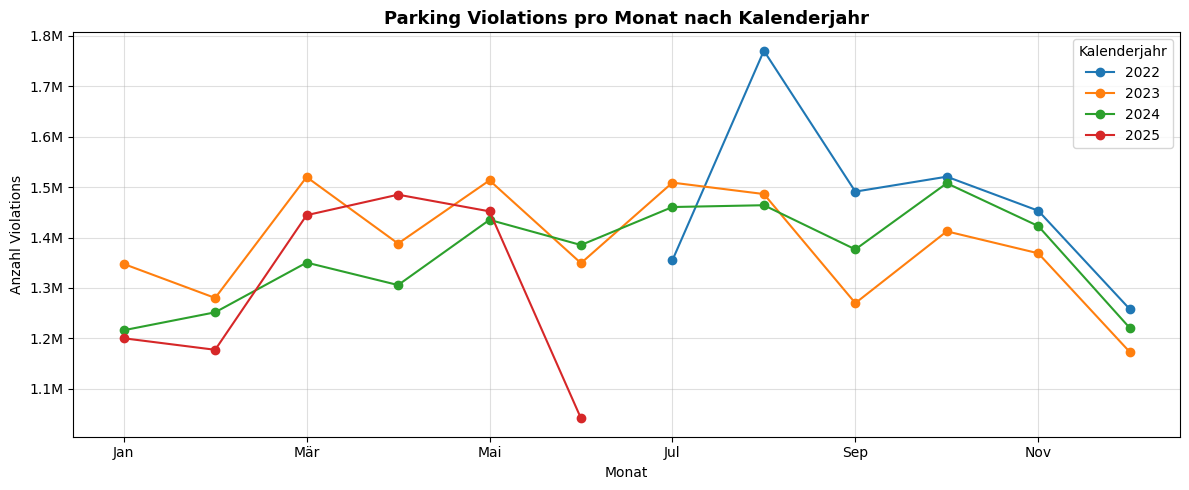

In [13]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Filter auf den sinnvollen Analyse-Zeitraum (vollständig abgedeckte Monate)
df_clean = df.filter(
    (f.col("issue_date_parsed") >= "2022-07-01") &
    (f.col("issue_date_parsed") <= "2025-06-30")
)
print(f"Records im Analyse-Zeitraum: {df_clean.count():,}")

# Aggregation: Anzahl Violations pro Kalenderjahr und Monat
monthly = df_clean.groupBy("issue_year", "issue_month") \
    .count() \
    .orderBy("issue_year", "issue_month") \
    .toPandas()

# Pivot: Monate als Zeilen, Kalenderjahre als Spalten
pivot_m = monthly.pivot(index="issue_month", columns="issue_year", values="count")
month_labels = {1:"Jan", 2:"Feb", 3:"Mär", 4:"Apr", 5:"Mai", 6:"Jun",
                7:"Jul", 8:"Aug", 9:"Sep", 10:"Okt", 11:"Nov", 12:"Dez"}
pivot_m.index = pivot_m.index.map(month_labels)

# Plot
fig, ax = plt.subplots(figsize=(12, 5))
pivot_m.plot(marker="o", ax=ax)
ax.set_title("Parking Violations pro Monat nach Kalenderjahr", fontsize=13, fontweight="bold")
ax.set_xlabel("Monat")
ax.set_ylabel("Anzahl Violations")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
ax.grid(True, alpha=0.4)
ax.legend(title="Kalenderjahr")
plt.tight_layout()
plt.show()

Mit FY anstelle von Kalenderjahr
Issue Date Jul 2022 – Jun 2023 → FY2023
Issue Date Jul 2023 – Jun 2024 → FY2024
Issue Date Jul 2024 – Jun 2025 → FY2025

+----+----------+----------+--------+
|fy  |min       |max       |n       |
+----+----------+----------+--------+
|2023|2022-07-01|2023-06-30|17246732|
|2024|2023-07-01|2024-06-30|16162180|
|2025|2024-07-01|2025-06-30|16251490|
+----+----------+----------+--------+



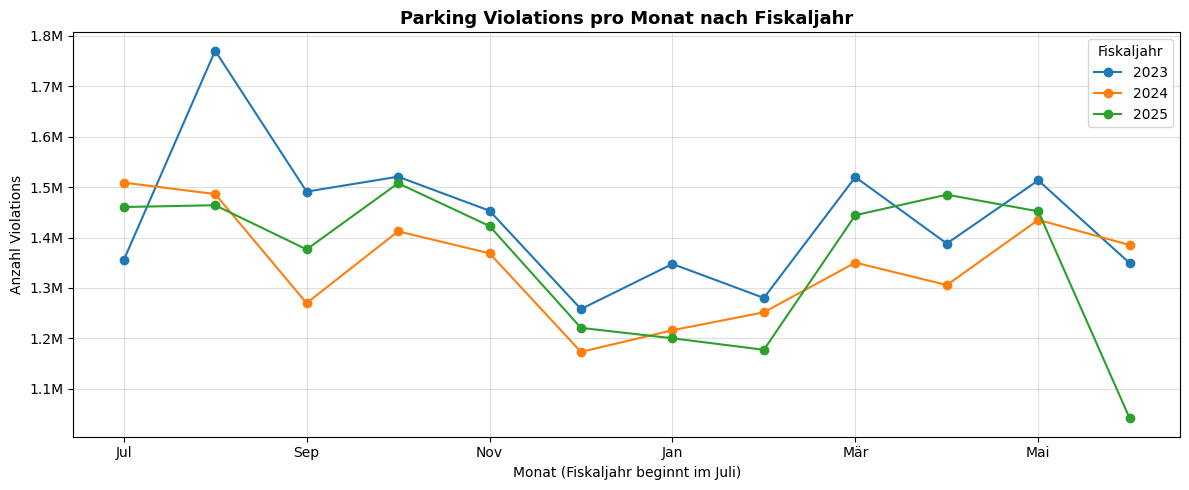

In [14]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Filter auf vollständige FY: Jul 2022 – Jun 2025
df_fy = df.filter(
    (f.col("issue_date_parsed") >= "2022-07-01") &
    (f.col("issue_date_parsed") <= "2025-06-30")
)

# Fiscal Year und Fiscal Month aus Issue Date ableiten
df_fy = df_fy.withColumn(
    "fy",
    f.when(f.col("issue_month") >= 7, f.col("issue_year") + 1)
     .otherwise(f.col("issue_year"))
).withColumn(
    "fm",
    f.when(f.col("issue_month") >= 7, f.col("issue_month") - 6)
     .otherwise(f.col("issue_month") + 6)
)

# Sanity Check
df_fy.groupBy("fy").agg(
    f.min("issue_date_parsed").alias("min"),
    f.max("issue_date_parsed").alias("max"),
    f.count("*").alias("n")
).orderBy("fy").show(truncate=False)

# Aggregation
monthly = df_fy.groupBy("fy", "fm") \
    .count() \
    .orderBy("fy", "fm") \
    .toPandas()

# Pivot: Fiscal Months als Zeilen, Fiscal Years als Spalten
pivot_m = monthly.pivot(index="fm", columns="fy", values="count")

# Fiscal-Month-Labels: 1=Jul, ..., 12=Jun
fm_labels = {1:"Jul", 2:"Aug", 3:"Sep", 4:"Okt", 5:"Nov", 6:"Dez",
             7:"Jan", 8:"Feb", 9:"Mär", 10:"Apr", 11:"Mai", 12:"Jun"}
pivot_m.index = pivot_m.index.map(fm_labels)

# Plot
fig, ax = plt.subplots(figsize=(12, 5))
pivot_m.plot(marker="o", ax=ax)
ax.set_title("Parking Violations pro Monat nach Fiskaljahr", fontsize=13, fontweight="bold")
ax.set_xlabel("Monat (Fiskaljahr beginnt im Juli)")
ax.set_ylabel("Anzahl Violations")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
ax.grid(True, alpha=0.4)
ax.legend(title="Fiskaljahr")
plt.tight_layout()
plt.show()

In [7]:
spark.stop()